In [1]:
from ilovebandits.handlers import RandForestHandler
from ilovebandits.agents import RandomForestTsAgent, RandomForestUcbAgent
from ilovebandits.exceptions import AgentNotFullyUpdatedError
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.datasets import make_regression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.utils.validation import check_is_fitted

import pytest

In [2]:
def get_classification_data(random_state, n_features=5, n_samples=5000):
    """Note about n_features: number of features including the column
    that indicates the arm selection.
    """
    
    # Generate a binary classification dataset.
    x, y = make_classification(
        n_samples=n_samples,
        n_features=n_features,
        n_clusters_per_class=1,
        n_informative=n_features,
        n_redundant=0,
        n_repeated=0,
        random_state=random_state,
    )

    # Use last column as arm column. Convert values to integers in the range [0, n_features-1].
    q1 = pd.DataFrame(x).describe().loc['25%', n_features-1]
    q2 = pd.DataFrame(x).describe().loc['50%', n_features-1]
    q3 = pd.DataFrame(x).describe().loc['75%', n_features-1]

    # print(f"Q1: {q1}, Q2: {q2}, Q3: {q3}")

    x[:, -1] = np.where(
        x[:, -1] < q1,
        0,
        np.where(
            x[:, -1] < q2,
            1,
            np.where(
                x[:, -1] < q3,
                2,
                3)
            )
        )
    
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

    c_train = x_train[:, :-1]  # Contextual features
    a_train = x_train[:, -1].astype(int)  # Arm selected

    c_test = x_test[:, :-1]  # Contextual features
    a_test = x_test[:, -1].astype(int)  # Arm selected
    
    data = {}
    data['x_train'] = x_train
    data['c_train'] = c_train
    data['a_train'] = a_train
    data['y_train'] = y_train
    data['x_test'] = x_test
    data['c_test'] = c_test
    data['a_test'] = a_test
    data['y_test'] = y_test
    
    return data

def get_regression_data(random_state, n_features=5, n_samples=5000):
    """Note about n_features: number of features including the column
    that indicates the arm selection.
    """

    # Generate a regression dataset.
    x, y = make_regression(n_samples=n_samples, n_features=n_features, noise=1, random_state=random_state)

    # Use last column as arm column. Convert values to integers in the range [0, n_features-1].
    q1 = pd.DataFrame(x).describe().loc['25%', n_features-1]
    q2 = pd.DataFrame(x).describe().loc['50%', n_features-1]
    q3 = pd.DataFrame(x).describe().loc['75%', n_features-1]

    # print(f"Q1: {q1}, Q2: {q2}, Q3: {q3}")

    x[:, -1] = np.where(
        x[:, -1] < q1,
        0,
        np.where(
            x[:, -1] < q2,
            1,
            np.where(
                x[:, -1] < q3,
                2,
                3)
            )
        )
    
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

    c_train = x_train[:, :-1]  # Contextual features
    a_train = x_train[:, -1].astype(int)  # Arm selected

    c_test = x_test[:, :-1]  # Contextual features
    a_test = x_test[:, -1].astype(int)  # Arm selected
    
    data = {}
    data['x_train'] = x_train
    data['c_train'] = c_train
    data['a_train'] = a_train
    data['y_train'] = y_train
    data['x_test'] = x_test
    data['c_test'] = c_test
    data['a_test'] = a_test
    data['y_test'] = y_test
    
    return data
   

# Handler Classification

In [3]:
########## Load dataset 1
RANDOM_STATE = 123

data = get_classification_data(random_state=RANDOM_STATE)

x_train = data['x_train']
c_train = data['c_train']
a_train = data['a_train']
y_train = data['y_train']
x_test = data['x_test']
c_test = data['c_test'] 
a_test = data['a_test']
y_test = data['y_test']

In [4]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    min_samples_leaf=20,  # important for the assumptions of sample mean and sample standard deviation in leaf nodes for TEUCB (Tree Ensemble UCB) and TETS (Tree Ensemble Thompson Sampling)
    max_depth=3,
    criterion="log_loss",
    max_samples=None,
    # n_jobs=N_CORES,
    random_state=42,
)

In [5]:
rf_handler = RandForestHandler(base_model=rf_model)
rf_handler.fit(X=x_train, y=y_train)

RandForestHandler(base_model=RandomForestClassifier(criterion='log_loss',
                                                    max_depth=3,
                                                    min_samples_leaf=20,
                                                    random_state=42))

In [6]:
rf_preds = rf_handler.model_.predict_proba(x_test)[
    :, 1
] 
# Assuming binary classification, we take the probability of the positive class
means, vars, counts = rf_handler.predict(x_test)
print(f"Are both predictions equal? sklearn vs manual implementation {np.allclose(rf_preds, means)}")

Are both predictions equal? sklearn vs manual implementation True


In [7]:
results_df = pd.DataFrame({'rf_preds':rf_preds, 'means':means, 'vars':vars, 'std':vars**0.5, 'counts':counts})
results_df

,rf_preds,means,vars,std,counts
0,0.077779,0.077779,5.212679e-07,0.000722,119260.0
1,0.085992,0.085992,7.625575e-07,0.000873,114522.0
2,0.927136,0.927136,1.070896e-06,0.001035,73631.0
3,0.245531,0.245531,2.076986e-06,0.001441,102930.0
4,0.949905,0.949905,5.040008e-07,0.000710,86532.0
...,...,...,...,...,...
995,0.738597,0.738597,2.635653e-06,0.001623,83373.0
996,0.589749,0.589749,3.558469e-06,0.001886,84841.0
997,0.851753,0.851753,1.385850e-06,0.001177,91274.0
998,0.707148,0.707148,2.016308e-06,0.001420,94756.0


# Handler Regression

In [8]:
data = get_regression_data(random_state=RANDOM_STATE)

x_train = data['x_train']
c_train = data['c_train']
a_train = data['a_train']
y_train = data['y_train']
x_test = data['x_test']
c_test = data['c_test'] 
a_test = data['a_test']
y_test = data['y_test']

In [9]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    min_samples_leaf=2,  # important for the assumptions of sample mean and sample standard deviation in leaf nodes for TEUCB (Tree Ensemble UCB) and TETS (Tree Ensemble Thompson Sampling)
    max_depth=5,
    criterion="squared_error",
    max_samples=None,
    # n_jobs=N_CORES,
    random_state=42,
)

In [10]:
rf_handler = RandForestHandler(base_model=rf_model)
rf_handler.fit(X=x_train, y=y_train)

RandForestHandler(base_model=RandomForestRegressor(max_depth=5,
                                                   min_samples_leaf=2,
                                                   random_state=42))

In [11]:
rf_preds = rf_handler.model_.predict(x_test)
# Assuming binary classification, we take the probability of the positive class
means, vars, counts = rf_handler.predict(x_test)
print(f"Are both predictions equal? sklearn vs manual implementation {np.allclose(rf_preds, means)}")

Are both predictions equal? sklearn vs manual implementation True


In [12]:
results_df = pd.DataFrame({'rf_preds':rf_preds, 'means':means, 'vars':vars, 'std':vars**0.5, 'counts':counts})
results_df

,rf_preds,means,vars,std,counts
0,64.412935,64.412935,0.335964,0.579624,18276.0
1,-70.560294,-70.560294,0.346952,0.589026,14671.0
2,-113.841651,-113.841651,0.662379,0.813867,8219.0
3,-88.237366,-88.237366,0.176232,0.419800,23041.0
4,20.986912,20.986912,0.172065,0.414807,25843.0
...,...,...,...,...,...
995,156.246053,156.246053,0.519087,0.720477,10846.0
996,-78.972648,-78.972648,0.354435,0.595344,14369.0
997,59.083190,59.083190,0.202853,0.450392,25581.0
998,-20.791327,-20.791327,0.137360,0.370621,31252.0


# basic handler with toy problem

In [13]:
n_estimators = 2
min_samples_leaf = 2
max_depth = 1
rf_avg_ = 1 / n_estimators
x_red = np.array([[-1.03235211,  0.01772303,  0.        ],
       [-0.67657322,  0.20022868,  1.        ],
       [ 1.38427582, -0.6641666 ,  1.        ],
       [ 0.42262633,  0.32744341,  1.        ],
       [ 1.67628789, -0.91734343,  2.        ],
       [ 1.629431  , -1.34926428,  0.        ],
       [-0.1284255 , -1.47691442,  3.        ],
       [-0.2713071 ,  2.45868241,  3.        ],
       [-1.2639901 ,  0.53765843,  1.        ],
       [-1.59933577,  1.71283289,  0.        ]])
y_red = np.array([ -20.06877974,  -21.82492121,  143.91112466,  157.82843687,
        -71.18482613, -133.64017262,  -46.1331373 ,   39.40058786,
        -32.30772486,  -44.25425066])

print(x_red.shape)
print(y_red.shape)

(10, 3)
(10,)


In [14]:
rf_model = RandomForestRegressor(
    n_estimators=n_estimators,
    min_samples_leaf=min_samples_leaf,  # important for the assumptions of sample mean and sample standard deviation in leaf nodes for TEUCB (Tree Ensemble UCB) and TETS (Tree Ensemble Thompson Sampling)
    max_depth=max_depth,
    criterion="squared_error",
    max_samples=None,
    # n_jobs=N_CORES,
    random_state=42,
)

In [15]:
rf_handler = RandForestHandler(base_model=rf_model)
rf_handler.fit(X=x_red, y=y_red)

RandForestHandler(base_model=RandomForestRegressor(max_depth=1,
                                                   min_samples_leaf=2,
                                                   n_estimators=2,
                                                   random_state=42))

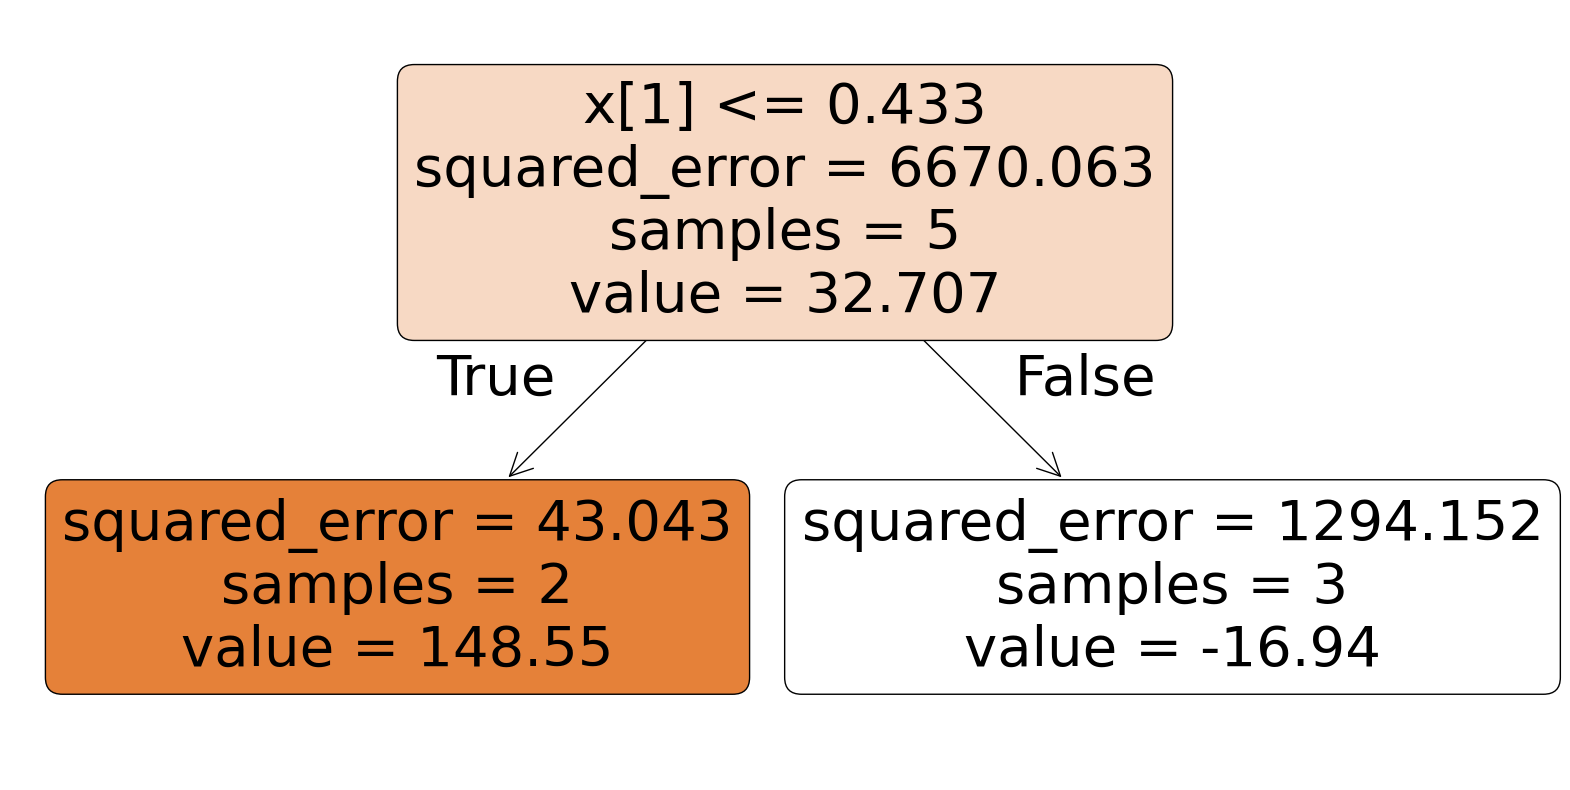

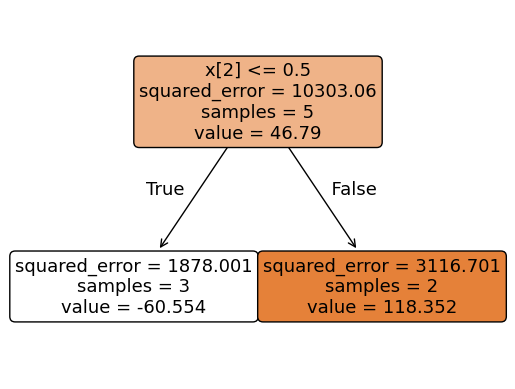

In [16]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
tree.plot_tree(
    rf_handler.model_.estimators_[0],
    # feature_names=iris.feature_names,
    # class_names=iris.target_names,
    filled=True,
    rounded=True
)
plt.show()

tree.plot_tree(
    rf_handler.model_.estimators_[1],
    filled=True,
    rounded=True
)
plt.show()

In [17]:
from sklearn.ensemble._forest import _generate_sample_indices
n_samples = len(x_red)
n_samples_bootstrap = n_samples


train_indices = [
    _generate_sample_indices(rf_handler.model_.estimators_[sel_tree].random_state, n_samples, n_samples_bootstrap)
    for sel_tree in range(len(rf_handler.model_.estimators_))
]
x_train_trees = [x_red[indices] for indices in train_indices]
y_train_trees = [y_red[indices] for indices in train_indices]


In [18]:
tree_1_cond = x_train_trees[0][:, 1]<=0.433
tree_2_cond = x_train_trees[1][:, 2]<=0.5

tree1_leaf1_count = len(rf_avg_*y_train_trees[0][tree_1_cond])
tree1_leaf2_count = len(rf_avg_*y_train_trees[0][~tree_1_cond])
tree2_leaf1_count = len(rf_avg_*y_train_trees[1][tree_2_cond])
tree2_leaf2_count =  len(rf_avg_*y_train_trees[1][~tree_2_cond])

tree1_leaf1_mean = np.mean(rf_avg_*y_train_trees[0][tree_1_cond])
tree1_leaf2_mean = np.mean(rf_avg_*y_train_trees[0][~tree_1_cond])
tree2_leaf1_mean = np.mean(rf_avg_*y_train_trees[1][tree_2_cond])
tree2_leaf2_mean =  np.mean(rf_avg_*y_train_trees[1][~tree_2_cond])

tree1_leaf1_var = np.var(rf_avg_*y_train_trees[0][tree_1_cond])
tree1_leaf2_var = np.var(rf_avg_*y_train_trees[0][~tree_1_cond])
tree2_leaf1_var = np.var(rf_avg_*y_train_trees[1][tree_2_cond])
tree2_leaf2_var =  np.var(rf_avg_*y_train_trees[1][~tree_2_cond])

# Print all the calculated values
print("Please, note that the means, vars, counts are already multiplied by rf_avg_ (1/n_estimators)")
print("=== TREE 1 ===")
print(f"Leaf 1 - Count: {tree1_leaf1_count}, Mean: {tree1_leaf1_mean:.4f}, Var: {tree1_leaf1_var:.4f}")
print(f"Leaf 2 - Count: {tree1_leaf2_count}, Mean: {tree1_leaf2_mean:.4f}, Var: {tree1_leaf2_var:.4f}")

print("\n=== TREE 2 ===")
print(f"Leaf 1 - Count: {tree2_leaf1_count}, Mean: {tree2_leaf1_mean:.4f}, Var: {tree2_leaf1_var:.4f}")
print(f"Leaf 2 - Count: {tree2_leaf2_count}, Mean: {tree2_leaf2_mean:.4f}, Var: {tree2_leaf2_var:.4f}")



Please, note that the means, vars, counts are already multiplied by rf_avg_ (1/n_estimators)
=== TREE 1 ===
Leaf 1 - Count: 3, Mean: 74.2751, Var: 10.7606
Leaf 2 - Count: 7, Mean: -8.4698, Var: 323.5379

=== TREE 2 ===
Leaf 1 - Count: 4, Mean: -30.2772, Var: 469.5003
Leaf 2 - Count: 6, Mean: 59.1762, Var: 779.1753


In [19]:
assert rf_handler.uc_data_[0]['leaf_counts'][1] == pytest.approx(
    tree1_leaf1_count, 
    rel=1e-6) 
assert rf_handler.uc_data_[0]['leaf_counts'][2] == pytest.approx(
    tree1_leaf2_count, 
    rel=1e-6) 
assert rf_handler.uc_data_[1]['leaf_counts'][1] == pytest.approx(
    tree2_leaf1_count, 
    rel=1e-6) 
assert rf_handler.uc_data_[1]['leaf_counts'][2] == pytest.approx(
    tree2_leaf2_count, 
    rel=1e-6) 

assert rf_handler.uc_data_[0]['leaf_avg_vals'][1] == pytest.approx(
    tree1_leaf1_mean, 
    rel=1e-6) 
assert rf_handler.uc_data_[0]['leaf_avg_vals'][2] == pytest.approx(
    tree1_leaf2_mean, 
    rel=1e-6) 
assert rf_handler.uc_data_[1]['leaf_avg_vals'][1] == pytest.approx(
    tree2_leaf1_mean, 
    rel=1e-6) 
assert rf_handler.uc_data_[1]['leaf_avg_vals'][2] == pytest.approx(
    tree2_leaf2_mean, 
    rel=1e-6) 


assert rf_handler.uc_data_[0]['leaf_var_vals'][1] == pytest.approx(
    tree1_leaf1_var/tree1_leaf1_count, # remeber that the variance of the leaf output is the sample_variance/n_samples. See paper.
    rel=1e-5) 
assert rf_handler.uc_data_[0]['leaf_var_vals'][2] == pytest.approx(
    tree1_leaf2_var/tree1_leaf2_count, 
    rel=1e-5) 
assert rf_handler.uc_data_[1]['leaf_var_vals'][1] == pytest.approx(
    tree2_leaf1_var/tree2_leaf1_count, 
    rel=1e-5) 
assert rf_handler.uc_data_[1]['leaf_var_vals'][2] == pytest.approx(
    tree2_leaf2_var/tree2_leaf2_count, 
    rel=1e-5) 

In [20]:
x_check = np.array([[1.0, 1.0, 1.0]])

ref_count = tree1_leaf2_count + tree2_leaf2_count 
ref_mean = tree1_leaf2_mean + tree2_leaf2_mean
ref_var = (tree1_leaf2_var/tree1_leaf2_count  + tree2_leaf2_var/tree2_leaf2_count)

pred_mean, pred_var, pred_count = rf_handler.predict(x_check)

assert ref_count == pytest.approx(
    pred_count, 
    rel=1e-6) 
assert ref_mean == pytest.approx(
    pred_mean, 
    rel=1e-6) 
assert ref_var == pytest.approx(
    pred_var, 
    rel=1e-6) 

# Test Handler follow scikit learn conventions
(see comments in handlers.py to see how to pass the test)

In [158]:
# from sklearn.utils.estimator_checks import check_estimator
# check_estimator(RandForestHandler(base_model=RandomForestRegressor(random_state=42)))

# New agents

## test AgentNotFullyUpdatedError

In [31]:
arms=4
rf_model = RandomForestRegressor(
    n_estimators=100,
    min_samples_leaf=2,  # important for the assumptions of sample mean and sample standard deviation in leaf nodes for TEUCB (Tree Ensemble UCB) and TETS (Tree Ensemble Thompson Sampling)
    max_depth=5,
    criterion="squared_error",
    max_samples=None,
    # n_jobs=N_CORES,
    random_state=42,
)
rfts_agent = RandomForestTsAgent(
        arms=arms,
        vpar=1.0,
        base_model=rf_model,
        rng_seed=42,
        one_model_per_arm=False,
        samples_for_freq_est = 1,
    )

rfts_disjoint = RandomForestTsAgent(
        arms=arms,
        vpar=1.0,
        base_model=rf_model,
        rng_seed=42,
        one_model_per_arm=True,
        samples_for_freq_est = 1,
    )

with pytest.raises(AgentNotFullyUpdatedError):
    rfts_agent.partial_fast_update(c_train=c_train, a_train=a_train, r_train=y_train)
    rfts_disjoint.partial_fast_update(c_train=c_train, a_train=a_train, r_train=y_train)

## test clone and predictions

In [18]:
data = get_regression_data(random_state=RANDOM_STATE)

x_train = data['x_train']
c_train = data['c_train']
a_train = data['a_train']
y_train = data['y_train']
x_test = data['x_test']
c_test = data['c_test'] 
a_test = data['a_test']
y_test = data['y_test']

In [32]:
rfts_agent.update_agent(c_train=c_train, a_train=a_train, r_train=y_train)
rfts_disjoint.update_agent(c_train=c_train, a_train=a_train, r_train=y_train)

In [ ]:
# This should be fitted:
check_is_fitted(rfts_agent.model.model_)

In [ ]:
# This should not be fitted:
check_is_fitted(rf_model)

NotFittedError: This RandomForestRegressor instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [ ]:
# This should be fitted:
check_is_fitted(rfts_agent.model)


In [ ]:
# This should not be fitted:
check_is_fitted(rfts_agent.base_estimator)

NotFittedError: This RandForestHandler instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [ ]:
# For the disjoint option, check that each model is different:
pd.DataFrame(
    {f"pred_{i}": model.predict(c_test)[0] for i, model in enumerate(rfts_disjoint.models)}
)

,pred_0,pred_1,pred_2,pred_3
0,-34.823246,-7.469527,84.607560,119.805781
1,-128.899926,-71.203641,-85.678990,-29.680984
2,-131.313883,-167.244230,-56.181941,-97.669083
3,-159.775138,-108.490158,-76.304794,-86.334491
4,-11.828471,47.919568,63.320683,88.126093
...,...,...,...,...
995,106.314255,169.874907,135.369202,193.287757
996,-128.373913,-57.316944,-74.836550,-52.409223
997,52.992754,71.780373,93.508144,128.302088
998,-62.298321,-44.080559,18.877659,3.714194


In [37]:
rfts_disjoint.models

[RandForestHandler(base_model=RandomForestRegressor(max_depth=5,
                                                    min_samples_leaf=2,
                                                    random_state=42)),
 RandForestHandler(base_model=RandomForestRegressor(max_depth=5,
                                                    min_samples_leaf=2,
                                                    random_state=42)),
 RandForestHandler(base_model=RandomForestRegressor(max_depth=5,
                                                    min_samples_leaf=2,
                                                    random_state=42)),
 RandForestHandler(base_model=RandomForestRegressor(max_depth=5,
                                                    min_samples_leaf=2,
                                                    random_state=42))]

In [60]:
# For the disjoint option, check that predictions are the same than a random forest model
for arm in range(arms):
    preds_ilove = rfts_disjoint.models[arm].predict(c_test[a_test==arm])[0]
    preds_ref = rf_model.fit(c_train[a_train==arm], y_train[a_train==arm]).predict(c_test[a_test==arm])
    print(f"Are both predictions equal? sklearn vs manual implementation {np.allclose(preds_ilove, preds_ref)}")

Are both predictions equal? sklearn vs manual implementation True
Are both predictions equal? sklearn vs manual implementation True
Are both predictions equal? sklearn vs manual implementation True
Are both predictions equal? sklearn vs manual implementation True


In [61]:
# For the hybrid option, check that predictions are the same than a random forest model
preds_ilove = rfts_agent.model.predict(x_test)[0]
preds_ref = rf_model.fit(x_train, y_train).predict(x_test)
print(f"Are both predictions equal? sklearn vs manual implementation {np.allclose(preds_ilove, preds_ref)}")

Are both predictions equal? sklearn vs manual implementation True


small debug

In [24]:
data = get_regression_data(random_state=RANDOM_STATE)

x_train = data['x_train']
c_train = data['c_train']
a_train = data['a_train']
y_train = data['y_train']
x_test = data['x_test']
c_test = data['c_test'] 
a_test = data['a_test']
y_test = data['y_test']

rfts = RandomForestTsAgent(
        arms=4,
        vpar=1.0,
        base_model=RandomForestRegressor(max_samples=None, random_state=42),
        rng_seed=42,
        one_model_per_arm=False,
        samples_for_freq_est = 1,
    )
rfts_disjoint = RandomForestTsAgent(
        arms=4,
        vpar=1.0,
        base_model=RandomForestRegressor(max_samples=None, random_state=42),
        rng_seed=42,
        one_model_per_arm=True,
        samples_for_freq_est = 1,
    )

In [25]:
from sklearn.base import clone
rf_model = clone(rfts.base_estimator.base_model)
rfts.update_agent(c_train=c_train, a_train=a_train, r_train=y_train)

In [27]:
preds_ilove = rfts.model.predict(x_test)[0]
preds_ref = rf_model.fit(x_train, y_train).predict(x_test)
print(pd.DataFrame({'preds_ilove': preds_ilove, 'preds_ref': preds_ref}))
np.allclose(preds_ilove, preds_ref)

     preds_ilove   preds_ref
0      84.392317   84.392317
1     -96.473004  -96.473004
2    -156.620759 -156.620759
3    -103.503517 -103.503517
4      56.418495   56.418495
..           ...         ...
995   191.125244  191.125244
996   -48.086488  -48.086488
997    69.393431   69.393431
998   -14.391199  -14.391199
999  -125.761311 -125.761311

[1000 rows x 2 columns]


True

## Test UCB and TS decisions with toy problem

In [40]:
n_estimators = 2
min_samples_leaf = 2
max_depth = 1
rf_avg_ = 1 / n_estimators
x_red = np.array([[-1.03235211,  0.01772303,  0.        ],
       [-0.67657322,  0.20022868,  1.        ],
       [ 1.38427582, -0.6641666 ,  1.        ],
       [ 0.42262633,  0.32744341,  1.        ],
       [ 1.67628789, -0.91734343,  2.        ],
       [ 1.629431  , -1.34926428,  0.        ],
       [-0.1284255 , -1.47691442,  3.        ],
       [-0.2713071 ,  2.45868241,  3.        ],
       [-1.2639901 ,  0.53765843,  1.        ],
       [-1.59933577,  1.71283289,  0.        ]])
y_red = np.array([ -20.06877974,  -21.82492121,  143.91112466,  157.82843687,
        -71.18482613, -133.64017262,  -46.1331373 ,   39.40058786,
        -32.30772486,  -44.25425066])

print(x_red.shape)
print(y_red.shape)

(10, 3)
(10,)


In [41]:
c_red = x_red[:,:2]
a_red = x_red[:,2].astype(int)

print(c_red.shape)
print(a_red.shape)
print(y_red.shape)

(10, 2)
(10,)
(10,)


In [42]:
rf_model = RandomForestRegressor(
    n_estimators=n_estimators,
    min_samples_leaf=min_samples_leaf,  # important for the assumptions of sample mean and sample standard deviation in leaf nodes for TEUCB (Tree Ensemble UCB) and TETS (Tree Ensemble Thompson Sampling)
    max_depth=max_depth,
    criterion="squared_error",
    max_samples=None,
    # n_jobs=N_CORES,
    random_state=42,
)

In [43]:
rf_handler = RandForestHandler(base_model=rf_model)
rf_handler.fit(X=x_red, y=y_red)

RandForestHandler(base_model=RandomForestRegressor(max_depth=1,
                                                   min_samples_leaf=2,
                                                   n_estimators=2,
                                                   random_state=42))

In [44]:
arms=4
vpar = 1.0
rfts_agent = RandomForestTsAgent(
        arms=arms,
        vpar=vpar,
        base_model=rf_model,
        rng_seed=42,
        one_model_per_arm=False,
        samples_for_freq_est = 20_000,
        n_rounds_random = 0,
        min_rewards_per_arm = 0,
    )


In [45]:
rfts_agent.update_agent(c_train=c_red, a_train=a_red, r_train=y_red)

In [46]:
c_check = np.array([[1.0, 1.0]])
rfts_agent.estimate_means_vars(c_check)

In [47]:
ref_means = [
    rf_handler.predict(np.concatenate((c_check, np.array([[arm]])), axis=1))[0] for arm in range(arms)
]
ref_var = [
    rf_handler.predict(np.concatenate((c_check, np.array([[arm]])), axis=1))[1] for arm in range(arms)
]
ref_count = [
    rf_handler.predict(np.concatenate((c_check, np.array([[arm]])), axis=1))[2] for arm in range(arms)
]


print(ref_means)
print(ref_var)
print(ref_count)

[array([-38.74696928]), array([50.70645603]), array([50.70645603]), array([50.70645603])]
[array([163.59479004]), array([176.08225673]), array([176.08225673]), array([176.08225673])]
[array([11.]), array([13.]), array([13.]), array([13.])]


In [48]:
import numpy.testing as npt
npt.assert_allclose(actual=ref_means, desired=rfts_agent.means, rtol=1e-7, atol=1e-8)
npt.assert_allclose(actual=ref_var, desired=rfts_agent.vars, rtol=1e-7, atol=1e-8)
npt.assert_allclose(actual=ref_count, desired=rfts_agent.counts, rtol=1e-7, atol=1e-8)


specific check thompson sampling

In [49]:
list_actions=[]
for _ in range(200_000):
    list_actions.append(
        rfts_agent.sample_qvals()
    )

In [50]:
rfts_agent.sample_qvals()

[array([-53.18844898]),
 array([43.45668355]),
 array([48.03462994]),
 array([69.05075335])]

In [51]:
a0, a1, a2, a3 = zip(*list_actions)

In [52]:
sampled_means = np.array([np.mean(a0), np.mean(a1), np.mean(a2), np.mean(a3)]).reshape(-1,1)
sampled_vars = np.array([np.var(a0), np.var(a1), np.var(a2), np.var(a3)]).reshape(-1,1)

In [53]:
npt.assert_allclose(
    actual=rfts_agent.means, 
    desired=sampled_means, rtol=1e-3, atol=1e-8
)

npt.assert_allclose(
    actual=rfts_agent.vars, 
    desired=sampled_vars, rtol=1e-2, atol=1e-8
)

In [54]:
# overwrite means and vars to force equal probability to choose each arm
rfts_agent.means = [1]* arms
rfts_agent.vars = [0.25] * arms
dic_freq_arms = rfts_agent._freq_arms()
for est_proba in dic_freq_arms.values():
    assert est_proba == pytest.approx(1/arms, rel=1e-2)

specific check ucb

In [55]:
rfucb_agent = RandomForestUcbAgent(
        arms=arms,
        vpar=1.0,
        base_model=rf_model,
        rng_seed=42,
        one_model_per_arm=False,
        n_rounds_random = 0,
        min_rewards_per_arm = 0,
    )

In [56]:
rfucb_agent.update_agent(c_train=c_red, a_train=a_red, r_train=y_red)

In [57]:
c_check = np.array([[1.0, 1.0]])
rfucb_agent.estimate_means_vars(c_check)

In [ ]:
### UCB FORMULA TO CHECK ####
total_learning = len(a_red) # Total number of rounds
ref_qval_samples = []
for arm in range(arms):
    arm_count = ref_count[arm] # Original paper count
    ref_qval_samples.append(
        ref_means[arm] + np.sqrt(vpar * ref_var[arm] * np.log(total_learning - 1)/arm_count)
        )

[array([-33.03052972]),
 array([56.16181516]),
 array([56.16181516]),
 array([56.16181516])]

In [70]:
from ilovebandits.utils import argmax
_, prob_action = rfucb_agent.take_action(c_check)
_, ref_prob, _ = argmax(
            ref_qval_samples,
            rfucb_agent.rng,
        ) 

npt.assert_allclose(
    actual=rfucb_agent.last_qval_samples, 
    desired=ref_qval_samples, rtol=1e-2, atol=1e-8
)

assert pytest.approx(ref_prob, abs=0.01) == prob_action